In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from constant import EXPS_PATH, PMDATA_PATH, LIFESNAPS_PATH

In [2]:
fold = 0
seed = 0
norm_str = 'quantile_global'
seq_enc = 'transformer'
tab_enc = 'resnet'
exclude = 'label'
label_ratio = 1.0
unlabel_ratio = 1.0
exp = 'weights'
mode = 'clip'

In [3]:
def get_exp_path(dataset):
    run_name = f'{dataset}/{exp}/{mode}/{norm_str}/seq:{seq_enc}_tab:{tab_enc}/'
    exp_name = f'{run_name}/unlabel_rate_{int(unlabel_ratio * 100)}/'
    exp_name += f'label_rate_{int(label_ratio * 100)}/'
    fold_name = f'{exclude}/fold_{fold}/seed_{seed}/'
    exp_name += fold_name
    save_path = os.path.join(EXPS_PATH, exp_name)
    return save_path

In [4]:
def visualize_weights(dataset='lifesnaps', top_k=20, title1='Feature Importance', title2='Feature Importance'):
    dataset_exp_path = get_exp_path(dataset)
    if dataset == 'lifesnaps':
        data_path = os.path.join(LIFESNAPS_PATH, 'processed')
    elif dataset == 'pmdata':
        data_path = os.path.join(PMDATA_PATH, 'processed')
    
    with open(os.path.join(data_path, 'tabular_cols.txt'), 'r') as f:
        tab_cols = f.read().splitlines()
    with open(os.path.join(data_path, 'fitbit_cols.txt'), 'r') as f:
        seq_cols = f.read().splitlines()
    
    seq_fa = np.load(os.path.join(dataset_exp_path, 'common_fa.npy'))
    tab_fa = np.load(os.path.join(dataset_exp_path, 'tabular_fa.npy')).ravel()

    # plot feature importance in bar plot
    fig, ax = plt.subplots(figsize=(16, 10))
    feature_importance = list(zip(tab_cols, tab_fa))
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    top_k_features = feature_importance[:top_k]
    rest = feature_importance[top_k:]
    rest_sum = sum([abs(x[1]) for x in rest])
    top_k_features.append(('rest', rest_sum))
    feature_names, feature_values = zip(*top_k_features)
    
    # bar plot postive as red and negative as blue
    colors = ['red' if x > 0 else 'blue' for x in feature_values]
    abs_feature_values = [abs(x) for x in feature_values]
    ax.barh(feature_names, abs_feature_values, color=colors)
    
    plt.gca().invert_yaxis()
    for i, v in enumerate(abs_feature_values):
        original_v = feature_values[i]
        ax.text(v, i, f'{original_v*100:.2f}%', color='black', va='center')

    ax.set_xlabel('Feature Importance')
    ax.set_ylabel('Feature Name')
    ax.set_title(title1)
    plt.tight_layout()
    
    # save figure
    fig_name = f'{dataset}_tabuar_feature_importance.pdf'
    fig_path = os.path.join(dataset_exp_path, fig_name)
    plt.savefig(fig_path)
    
    # plot feature importance in heatmap
    fig, ax = plt.subplots(figsize=(16, 10))
    heatmap = ax.imshow(seq_fa, interpolation='nearest', aspect='auto')
    ax.set_xlabel('Hourly Index')
    ax.set_ylabel('Name of Channels')
    ax.set_title('Fitbit Feature Importance')
    cbar = plt.colorbar(heatmap)
    
    # set ytikcs
    ax.set_yticks(np.arange(len(seq_cols)))
    ax.set_yticklabels(seq_cols)
    ax.set_title(title2)
    
    # tight layout
    plt.tight_layout()
    
    fig_name = f'{dataset}_fitbit_feature_importance.pdf'
    fig_path = os.path.join(dataset_exp_path, fig_name)
    plt.savefig(fig_path)

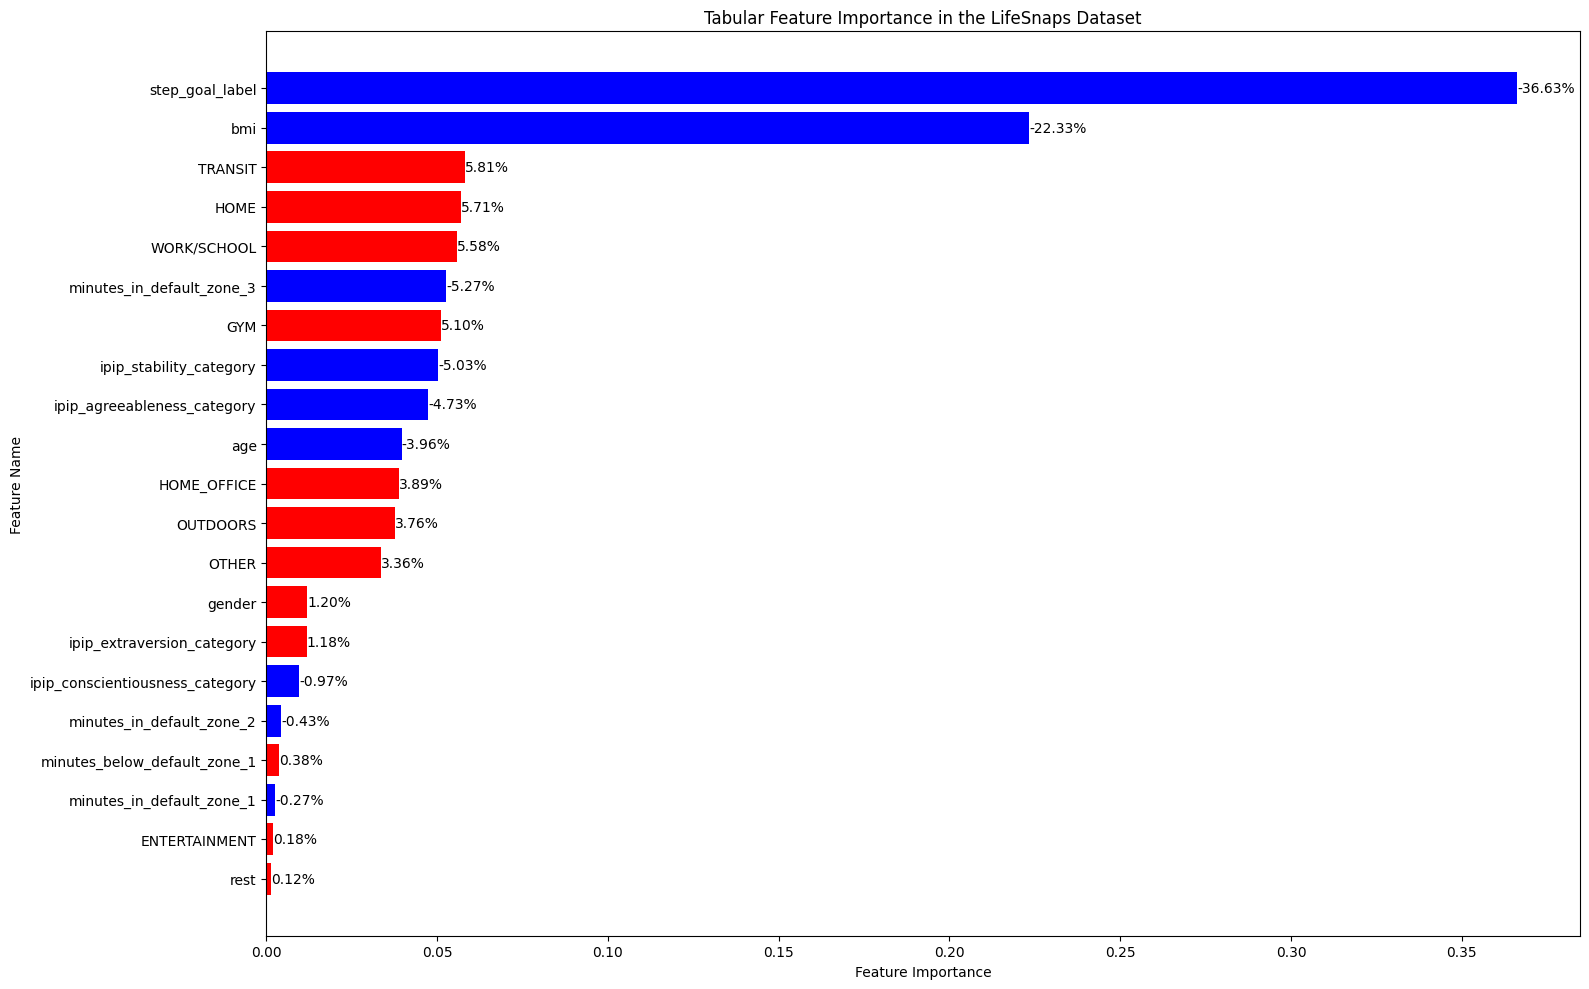

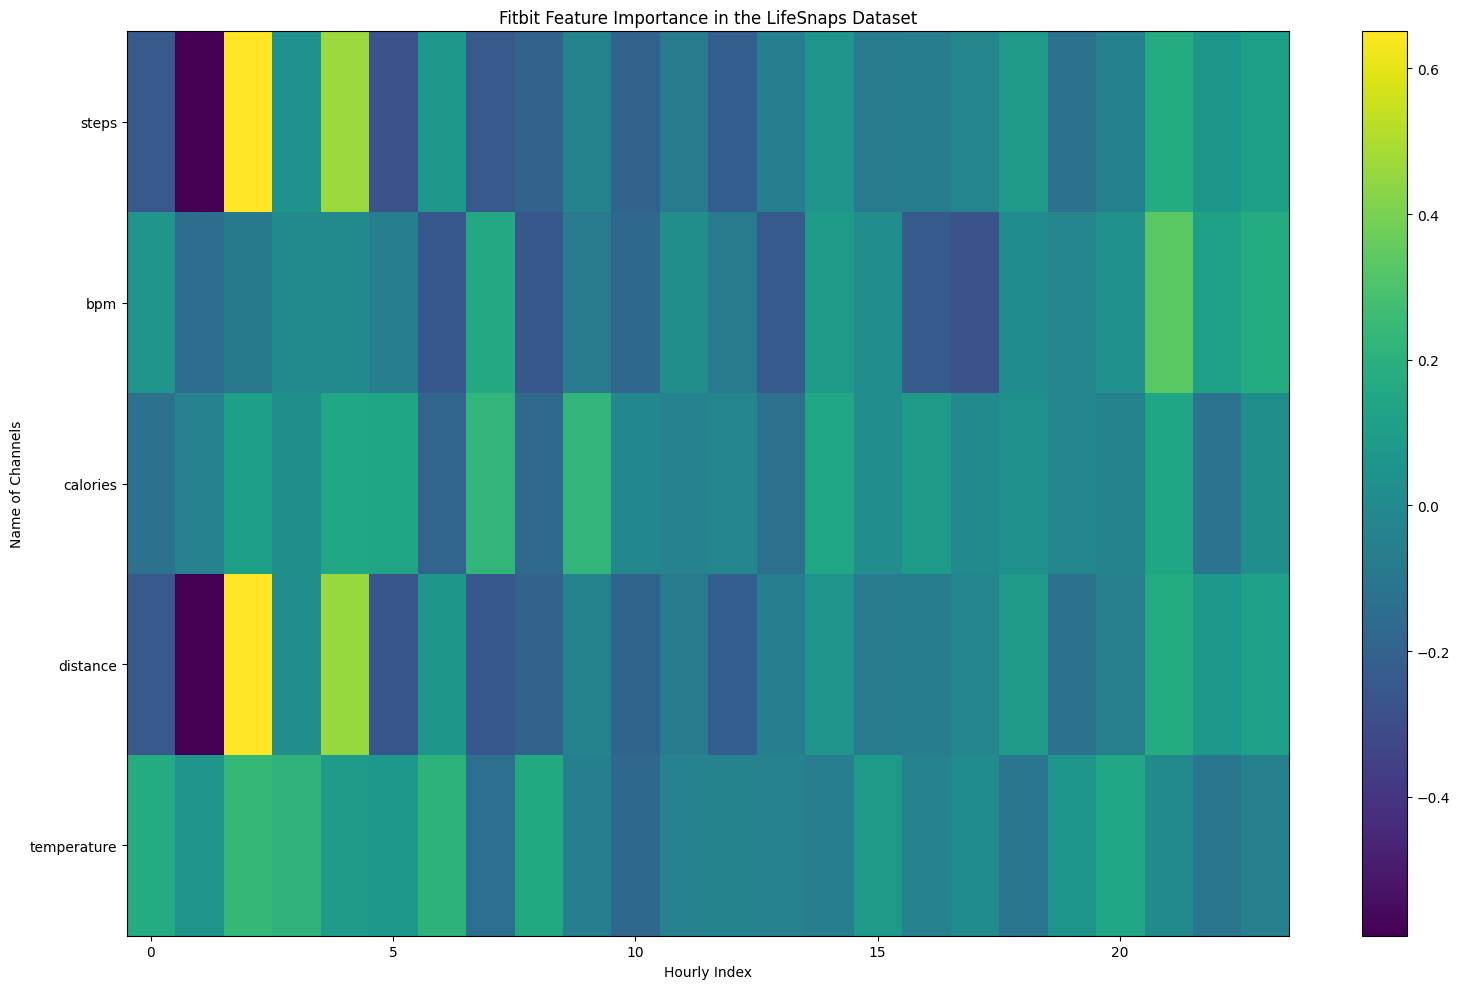

In [7]:
visualize_weights('lifesnaps', 20, title1='Tabular Feature Importance in the LifeSnaps Dataset', title2='Fitbit Feature Importance in the LifeSnaps Dataset')

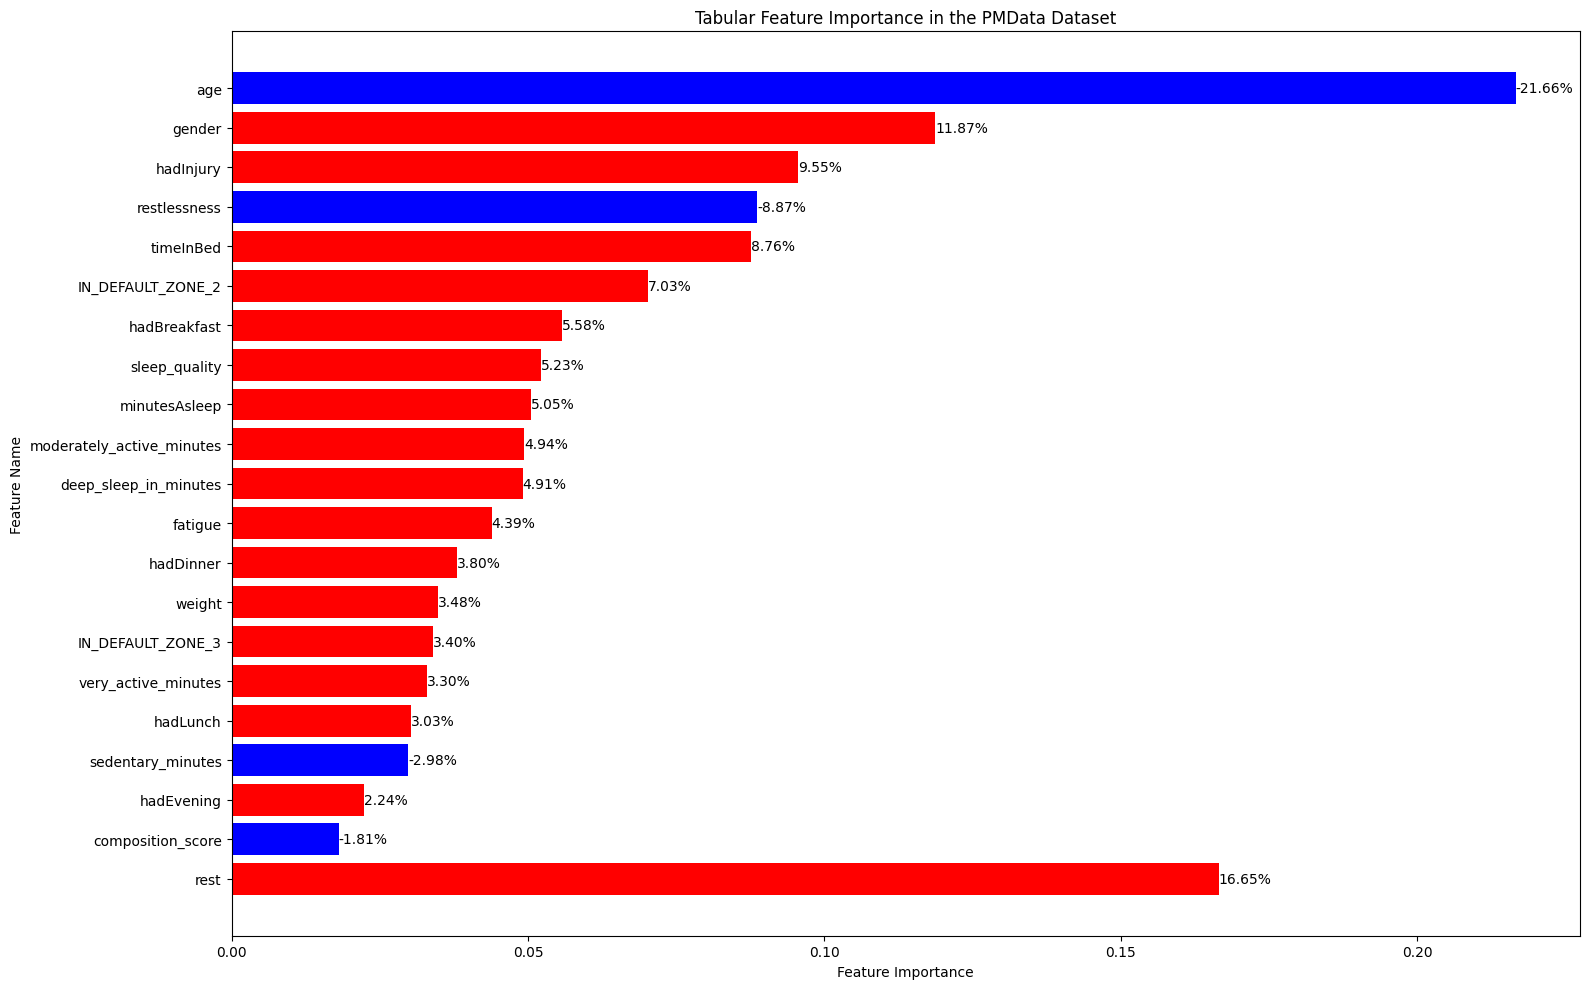

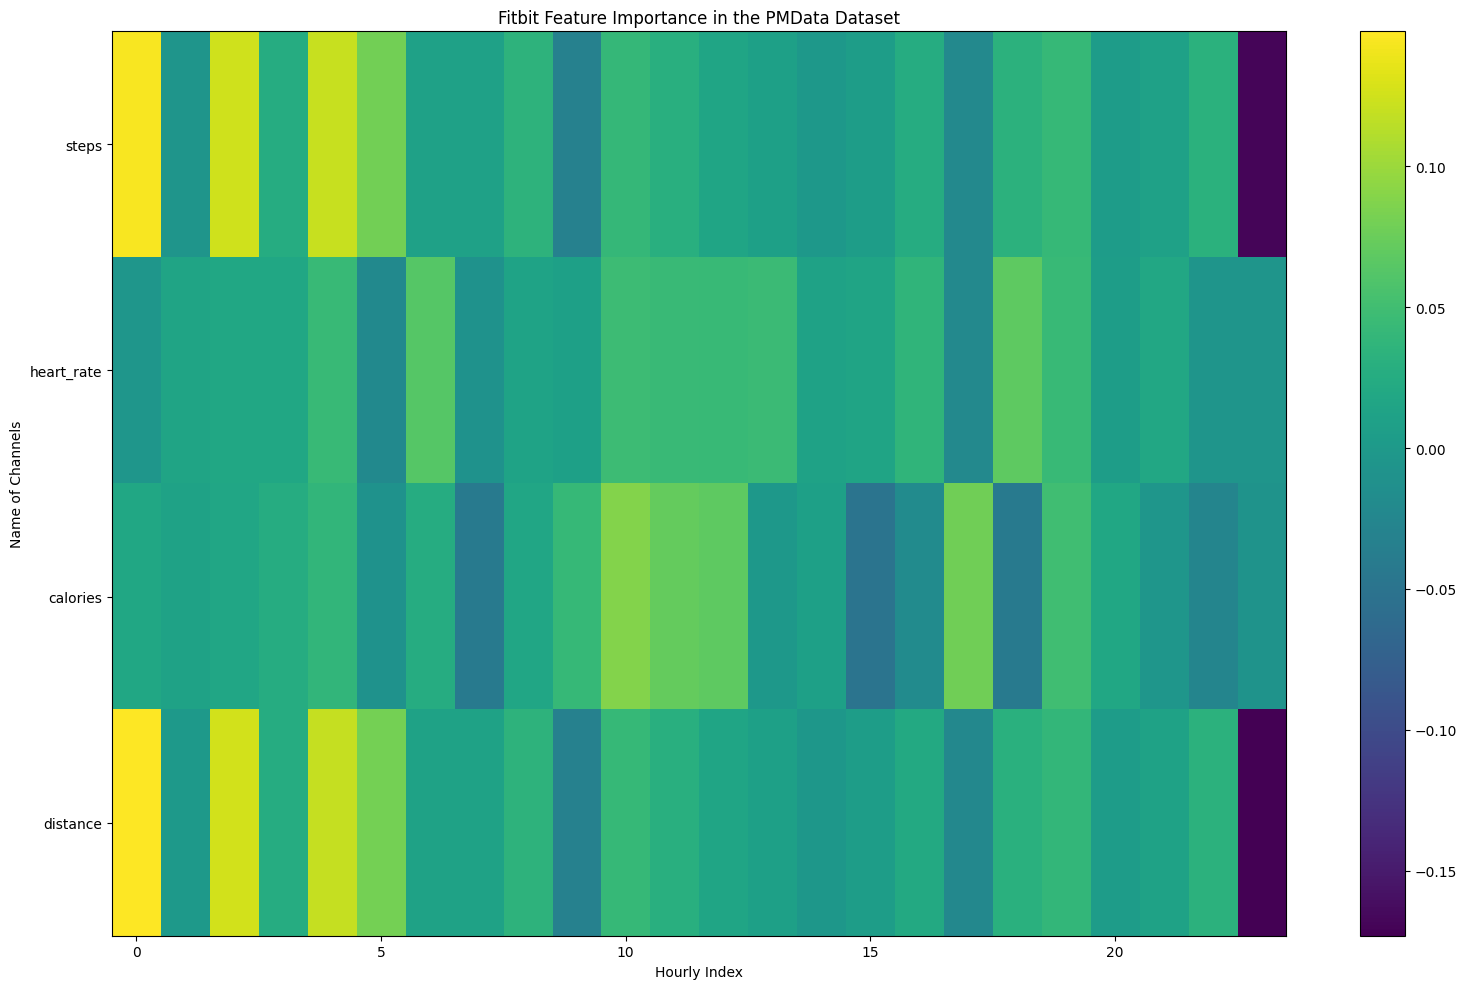

In [8]:
visualize_weights('pmdata', 20, title1='Tabular Feature Importance in the PMData Dataset', title2='Fitbit Feature Importance in the PMData Dataset')